In [29]:
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import lightgbm as lgb
import shap
from statsmodels.stats.outliers_influence import variance_inflation_factor
from catboost import CatBoostClassifier, Pool
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import joblib


# Variables a trabajar

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.\

Pregnancies: Número de embarazos del paciente (numérico) \
Glucose: Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)\
BloodPressure: Presión arterial diastólica (medida en mm Hg) (numérico)\
SkinThickness: Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)\
Insulin: Insulina sérica de 2 horas (medida en mu U/ml) (numérico)\
BMI: Índice de masa corporal (numérico)\
DiabetesPedigreeFunction: Función de pedigrí de diabetes (numérico)\
Age: Edad del paciente (numérico)\
Outcome: Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico, variable objetivo)

In [2]:
df=pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# Valores unicos, duplicados y faltantes

## Valores unicos

In [3]:
valores_unicos = df.nunique()
valores_unicos

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

No tenemos valores unicos

## Valores duplicados

In [4]:
print(df.duplicated().sum(),df.T.duplicated().sum())


0 0


no tenemos valores duplicados en filas ni en columnas

## Valores faltantes

In [5]:
def detectar_missing_ocultos(df, valores_sospechosos=[-1, 0, 999, 9999, -999]):
    reporte = {}

    for col in df.columns:
        info = {}

        # Missing reales
        info["NaN reales"] = df[col].isna().sum()

        # Detección de valores no numéricos en columnas "numéricas"
        col_forzada = pd.to_numeric(df[col], errors="coerce")
        info["Valores no numéricos ocultos"] = col_forzada.isna().sum() - df[col].isna().sum()

        # Cantidad de valores únicos 
        info["Valores únicos"] = df[col].nunique()

        reporte[col] = info

    return pd.DataFrame(reporte).T
detectar_missing_ocultos(df)

,NaN reales,Valores no numéricos ocultos,Valores únicos
Pregnancies,0,0,17
Glucose,0,0,136
BloodPressure,0,0,47
SkinThickness,0,0,51
Insulin,0,0,186
BMI,0,0,248
DiabetesPedigreeFunction,0,0,517
Age,0,0,52
Outcome,0,0,2


No hay valores faltantes

# Train test split

In [6]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Outliers

In [7]:
pd.set_option('display.float_format', '{:.3f}'.format)
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.000,3.743,3.313,0.000,1.000,3.000,6.000,17.000
Glucose,614.000,120.855,32.035,0.000,100.000,117.000,139.000,199.000
BloodPressure,614.000,69.415,18.513,0.000,64.000,72.000,80.000,122.000
SkinThickness,614.000,20.399,15.434,0.000,0.000,23.000,32.000,63.000
Insulin,614.000,81.438,116.235,0.000,0.000,42.500,129.750,846.000
BMI,614.000,31.983,7.741,0.000,27.100,32.000,36.375,67.100
DiabetesPedigreeFunction,614.000,0.469,0.337,0.078,0.241,0.372,0.614,2.420
Age,614.000,32.907,11.503,21.000,24.000,29.000,40.000,81.000


In [8]:
iso = IsolationForest(random_state=123)
df_num = X_train.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train)
df_num['outlier_flag'].value_counts()

outlier_flag
 1    544
-1     70
Name: count, dtype: int64

In [9]:
outliers = df_num[df_num["outlier_flag"] == -1]
outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,outlier_flag
60,2,84,0,0,0,0.000,0.304,21,-1
294,0,161,50,0,0,21.900,0.254,65,-1
673,3,123,100,35,240,57.300,0.880,22,-1
286,5,155,84,44,545,38.700,0.619,34,-1
28,13,145,82,19,110,22.200,0.245,57,-1
...,...,...,...,...,...,...,...,...,...
661,1,199,76,43,0,42.900,1.394,22,-1
99,1,122,90,51,220,49.700,0.325,31,-1
458,10,148,84,48,237,37.600,1.001,51,-1
270,10,101,86,37,0,45.600,1.136,38,-1


## Correlacion

### Correlacion con todos los datos

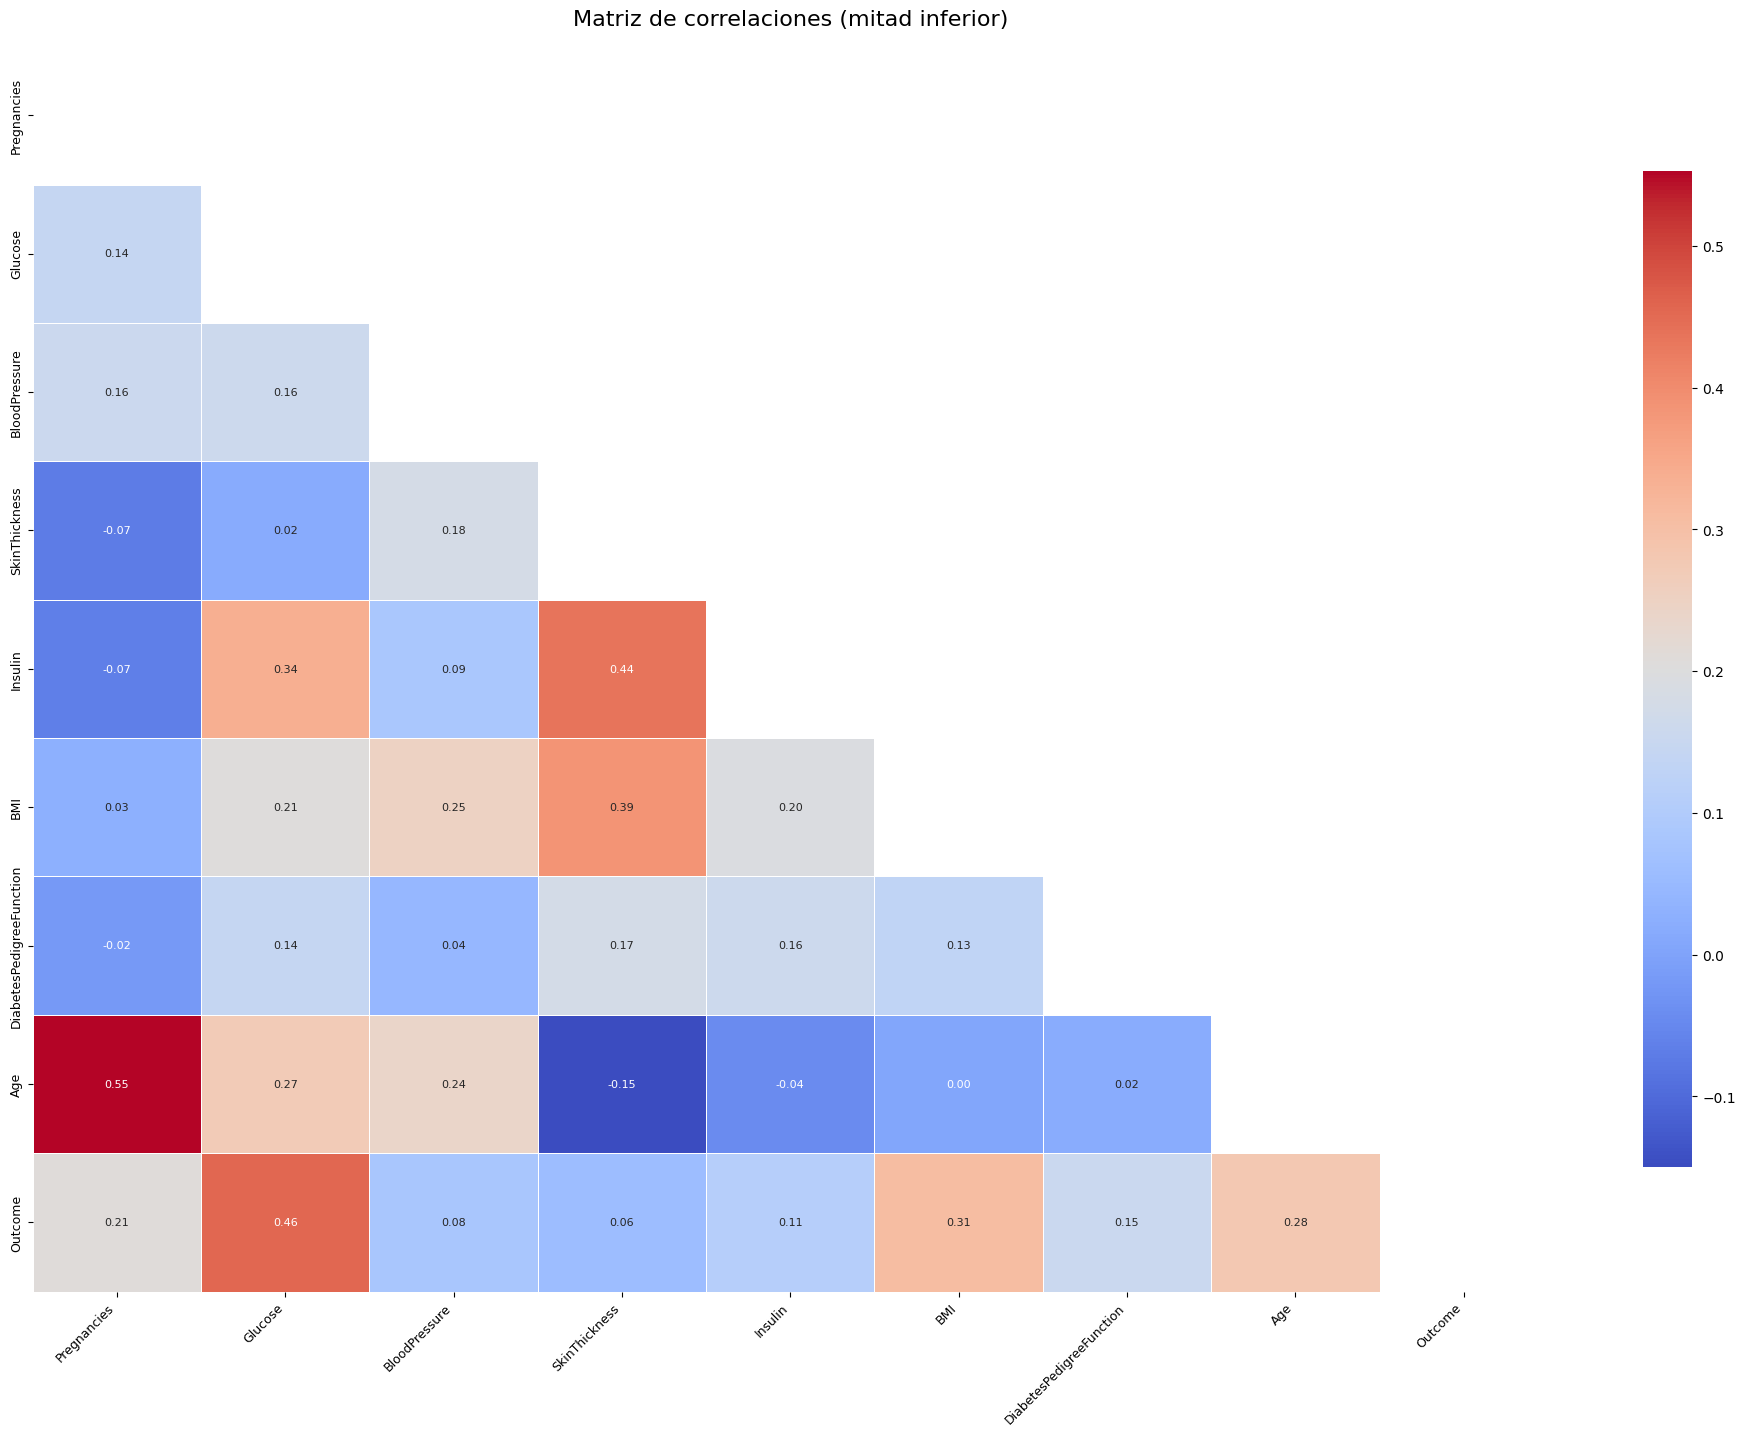

In [10]:
X_copy = X_train.copy()
X_copy['Outcome'] = Y_train
corr = X_copy.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

### Correlacion sin Outlier

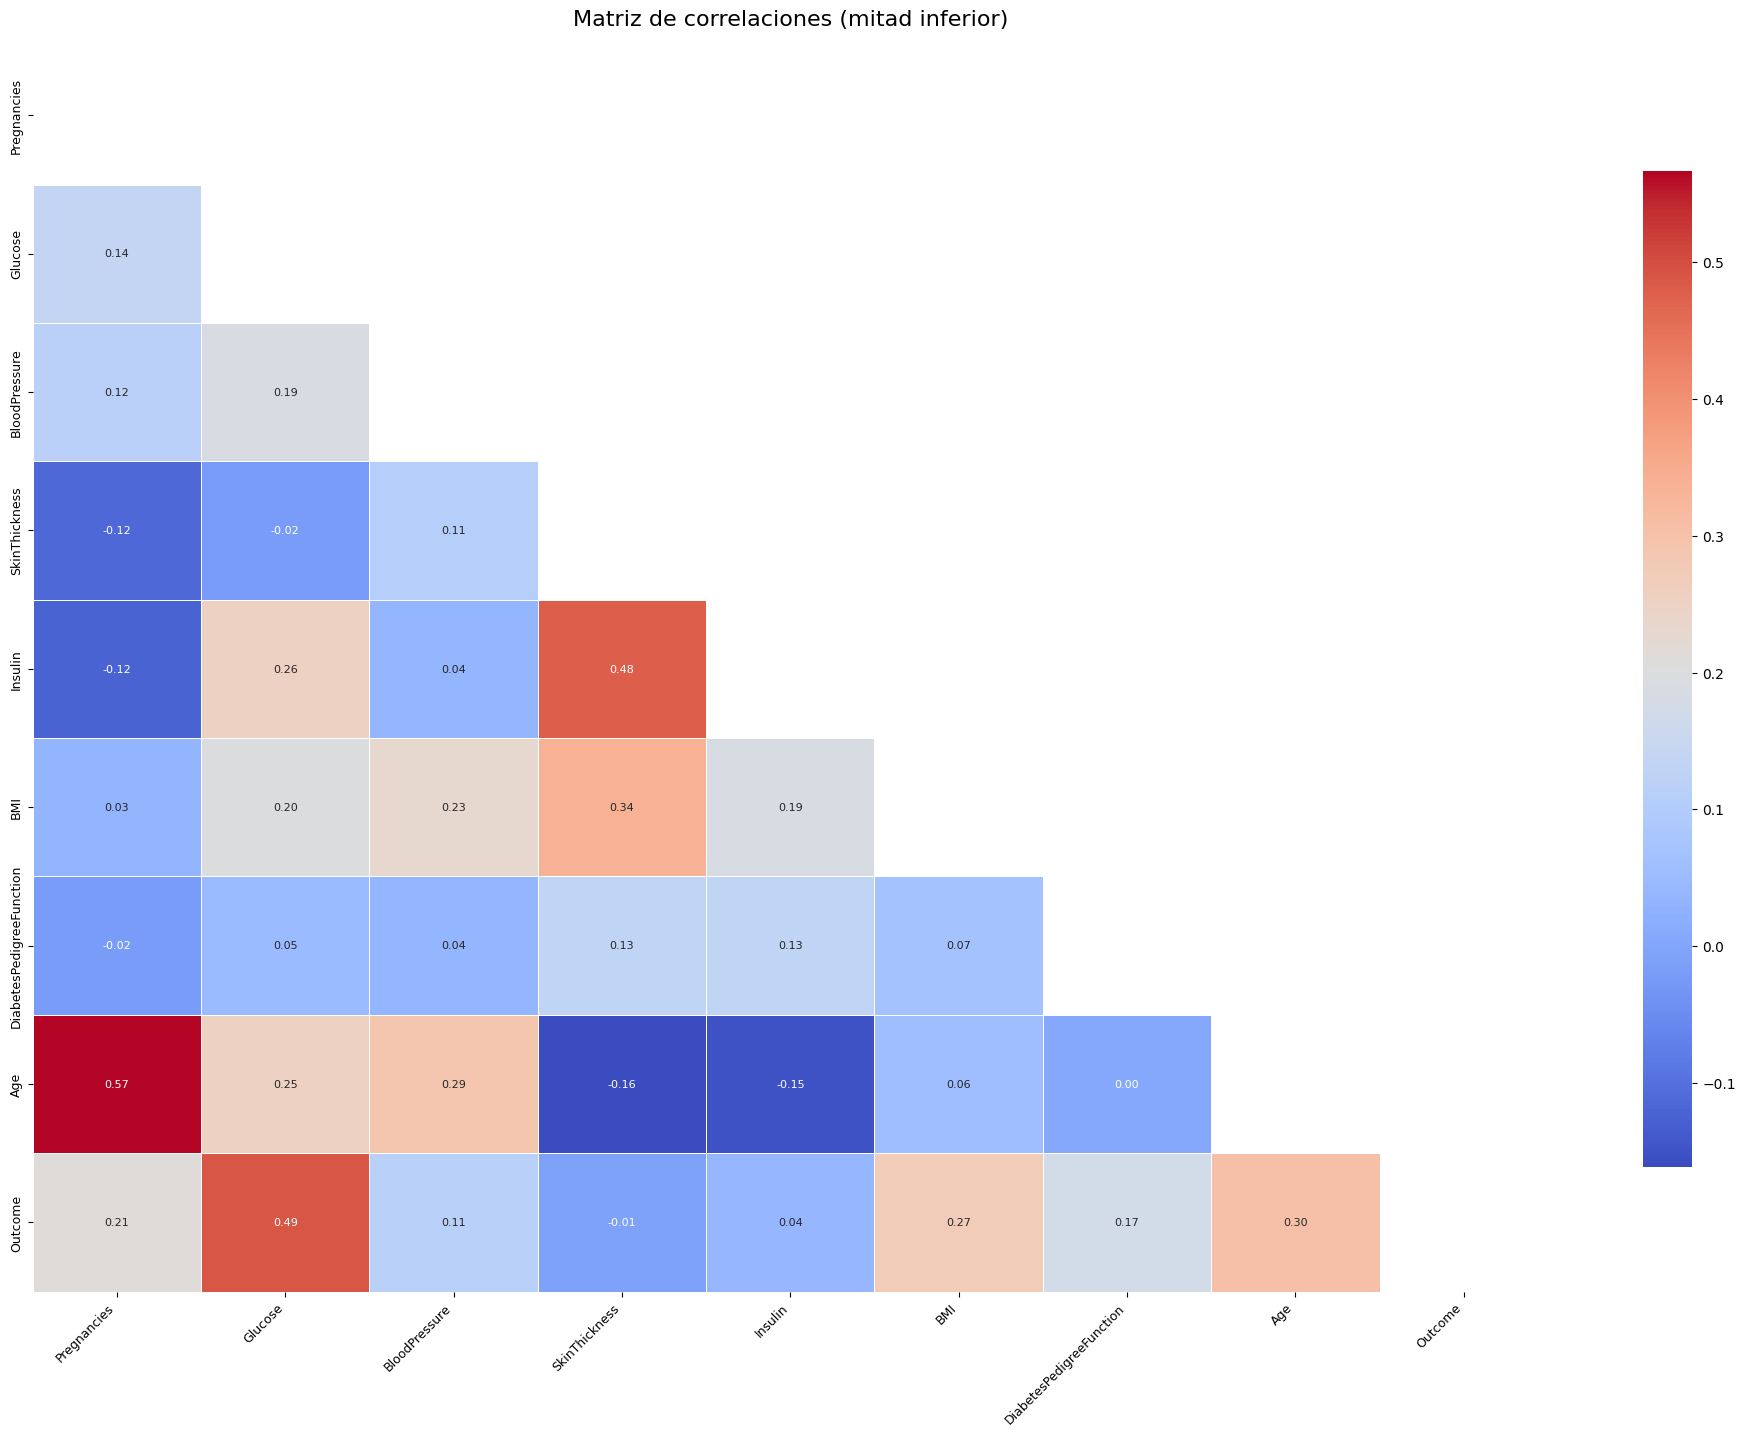

In [11]:
X_train_sin_outliers = X_train[df_num["outlier_flag"] != -1]
X_copy = X_train_sin_outliers.copy()
X_copy['Outcome'] = Y_train
corr = X_copy.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

Vemos que al sacar los outlier la correlacion no varia mucho y que tenemos una correlacion moderada en la edad y Glucose con la variable objetivo, y Insulin con SkinThickness. por ende en este punto decidimos mantenerlas, mas adelante veremos si el modelo se comporta mejor sin estas.

# Seleccion de caracteristicas

## Metodo 1 feature importance de RF

In [12]:

model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train, Y_train)
importances = model.feature_importances_/model.feature_importances_.sum()*100
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
df_rf_imp['rf_importance_acum'] = df_rf_imp['rf_importance'].cumsum()
df_rf_imp

,feature,rf_importance,rf_importance_acum
1,Glucose,25.886,25.886
5,BMI,16.998,42.885
7,Age,14.093,56.978
6,DiabetesPedigreeFunction,12.377,69.355
2,BloodPressure,8.813,78.168
0,Pregnancies,7.655,85.823
4,Insulin,7.612,93.435
3,SkinThickness,6.565,100.000


## Metodo 2 Metodo CatBoostClassifier

In [13]:
model = CatBoostClassifier(verbose=0)
model.fit(X_train, Y_train)
importances = model.get_feature_importance()
df_cat_imp = pd.DataFrame({'feature': X_train.columns,'cat_importance': importances}).sort_values(by='cat_importance', ascending=False)
df_cat_imp


,feature,cat_importance
1,Glucose,23.409
5,BMI,16.915
7,Age,15.068
6,DiabetesPedigreeFunction,11.747
4,Insulin,8.808
3,SkinThickness,8.517
2,BloodPressure,8.454
0,Pregnancies,7.081


## Metodo 3 SHAP

In [14]:
X_train1, X_val, Y_train1, Y_val = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)
model_lgbm = lgb.LGBMClassifier(random_state=42, n_jobs=-1).fit(X_train, Y_train)
explainer = shap.Explainer(model_lgbm, X_val)   
shap_vals = explainer(X_val).values
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,feature,shap_imp
1,Glucose,27.681
5,BMI,22.434
7,Age,15.241
6,DiabetesPedigreeFunction,12.382
2,BloodPressure,6.645
3,SkinThickness,5.950
4,Insulin,5.632
0,Pregnancies,4.036


### Union de metodos

In [15]:
df_importances = (
    df_rf_imp
    .merge(df_cat_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)
df_importances

,feature,rf_importance,rf_importance_acum,cat_importance,shap_imp
4,Glucose,25.886,25.886,23.409,27.681
1,BMI,16.998,42.885,16.915,22.434
0,Age,14.093,56.978,15.068,15.241
3,DiabetesPedigreeFunction,12.377,69.355,11.747,12.382
2,BloodPressure,8.813,78.168,8.454,6.645
6,Pregnancies,7.655,85.823,7.081,4.036
5,Insulin,7.612,93.435,8.808,5.632
7,SkinThickness,6.565,100.000,8.517,5.950


## Caracteristicas seleccionadas

In [16]:
df_filt = df_importances[(df_importances['rf_importance']>=2)|(df_importances['cat_importance']>=2)|(df_importances['shap_imp']>=2)] # Características seleccionadas 
df_filt

,feature,rf_importance,rf_importance_acum,cat_importance,shap_imp
4,Glucose,25.886,25.886,23.409,27.681
1,BMI,16.998,42.885,16.915,22.434
0,Age,14.093,56.978,15.068,15.241
3,DiabetesPedigreeFunction,12.377,69.355,11.747,12.382
2,BloodPressure,8.813,78.168,8.454,6.645
6,Pregnancies,7.655,85.823,7.081,4.036
5,Insulin,7.612,93.435,8.808,5.632
7,SkinThickness,6.565,100.000,8.517,5.950


### VIF

In [17]:
features = df_filt['feature']
vif = pd.Series([variance_inflation_factor(X_train[features].corr().values, i) for i in range(X_train[features].corr().shape[1])], index=X_train[features].columns)
df_vif = pd.Series(vif, name='vif').reset_index().rename(columns={'index': 'feature'})
df_vif_filt=pd.merge(df_vif, df_filt, on='feature' ,how='inner')
df_vif_filt

,feature,vif,rf_importance,rf_importance_acum,cat_importance,shap_imp
0,Glucose,2.979,25.886,25.886,23.409,27.681
1,BMI,2.571,16.998,42.885,16.915,22.434
2,Age,5.080,14.093,56.978,15.068,15.241
3,DiabetesPedigreeFunction,1.276,12.377,69.355,11.747,12.382
4,BloodPressure,1.826,8.813,78.168,8.454,6.645
5,Pregnancies,3.744,7.655,85.823,7.081,4.036
6,Insulin,3.862,7.612,93.435,8.808,5.632
7,SkinThickness,4.495,6.565,100.000,8.517,5.950


Con estos resultados tomamos la desicion de continuar con todas las caracteristicas, debido a que  no hay una alta colinealidad entre estas y todas las variables aportan informacion 

# Modelacion

## Árboles de decisión

In [18]:
model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
y_pred_default = model.predict(X_test)
print(f"f1_score: {f1_score(Y_test, y_pred_default)}")


f1_score: 0.6722689075630253


## Matriz

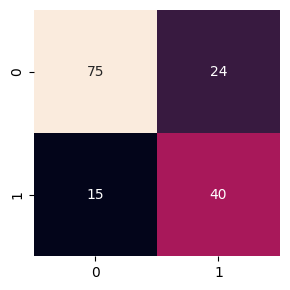

In [24]:
titanic_cm = confusion_matrix(Y_test, y_pred_default)
cm_df = pd.DataFrame(titanic_cm)
plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)
plt.tight_layout()
plt.show()

## Busquedad de Hiperparametros

### Busqueda Extensiva

In [25]:
parametros = {
    "max_depth": randint(0, 100),
    "min_samples_split": randint(0, 100),
    "min_samples_leaf": randint(0, 100),
    "criterion": ["gini", "entropy"]
}

# Definimos el clasificador
clf = DecisionTreeClassifier(random_state=42)

# Búsqueda aleatoria
search = RandomizedSearchCV(
    clf,
    param_distributions=parametros,
    n_iter=1000,          
    scoring="f1", 
    cv=5,
    n_jobs=-1,
    random_state=42
)

# Entrenamos
search.fit(X_train, Y_train)

# Resultados
print(" Mejores hiperparámetros:", search.best_params_)
print(" Mejor f1_score:", search.best_score_)

 Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 11, 'min_samples_split': 89}
 Mejor f1_score: 0.6980457058770269


/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
230 fits failed out of a total of 5000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "/home/vscode/.lo

### Busquedad Intensiva

In [26]:
parametros = {
    "max_depth": randint(0, 10),
    "min_samples_split": randint(30, 40),
    "min_samples_leaf": randint(10, 20),
    "criterion": ["gini", "entropy"]
}

# Definimos el clasificador
clf = DecisionTreeClassifier(random_state=42)

# Búsqueda aleatoria
search2 = RandomizedSearchCV(
    clf,
    param_distributions=parametros,
    n_iter=1000,          
    scoring="f1", 
    cv=5,
    n_jobs=-1,
    random_state=42
)

# Entrenamos
search2.fit(X_train, Y_train)

# Resultados
print(" Mejores hiperparámetros:", search.best_params_)
print(" Mejor f1_score:", search.best_score_)

 Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 11, 'min_samples_split': 89}
 Mejor f1_score: 0.6980457058770269


/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
490 fits failed out of a total of 5000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
490 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "/home/vscode/.l

### Aplicamos Hiperparametros

In [27]:
y_pred = search2.predict(X_test)
print("f1_score:", f1_score(Y_test, y_pred))


f1_score: 0.6065573770491803


# Grafica y analisis de resultados

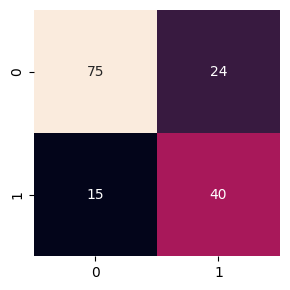

              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [28]:
matriz_cm = confusion_matrix(Y_test, y_pred_default)
cm_df = pd.DataFrame(matriz_cm)
plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)
plt.tight_layout()
plt.show() 
print(classification_report(Y_test, y_pred_default))

de acuerdo a lo anteriomente observado, vemos que el mejor modelo es el que viene por Dafault ya que es que mejor F1 Score presenta frente a las versiones con hiperparametros. a su vez presenta un acurracy del 75%.
Diabetes Negativa (0)
Tenemos que hay 99 casos de negativo en diabetes, de los cuales el modelo tiene un 83% de presicion, de los cuales el 76% son verdaderos negativos.
Diabetes Positiva (1)
Tenemos que hay 55 casos de negativo en diabetes, de los cuales el modelo tiene un 62% de presicion, de los cuales el 73% son verdaderos positivos.

por en de el modelo tiende a detectar mejor a los pasiates que NO tienen diabetes, inferimos que posiblemente es por la poca cantidad de datos que hay en los casos positivos

# Guardamos modelo

In [30]:
joblib.dump(model, 'modelo_dt_diabetes.pkl')

['modelo_dt_diabetes.pkl']